# 11.3.1 固定随机数的同步传播

## 学习目标与先修知识

写出同步 SIR 更新并复查传播与恢复事件（event）。

先修：11.1 接触边语义；5.4 马尔可夫（Markov）转移与条件概率（conditional probability）。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

在细胞或个体接触网络中，感染事件和恢复事件同一步可能同时发生。若按数组（array）顺序立刻修改状态（state），传播结果会依赖循环顺序。怎样让每个事件都只读取同一时刻的状态，并用预先给定的随机数重放？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

三节点路径左端先感染：检查第一步只会使中间节点变 I，右端最早下一步才可能感染。

In [2]:
print('状态编码0=S、1=I、2=R；同步更新读取旧状态[1,0,0]。')

状态编码0=S、1=I、2=R；同步更新读取旧状态[1,0,0]。


## 模型假设

无向固定接触边，每条感染邻边每步以概率（probability） $\beta$ 独立尝试；每位旧感染者以概率 $\gamma$ 恢复。预先生成 $[0,1)$ 随机数表，感染判定使用接收者 i 到旧感染邻居 j 的定向槽。每一步同时更新所有节点的 S、I、R 状态。

## 数学解释与推导

若节点 $i$ 当前易感，给定感染邻居集合 $I_i$ 且抽样相互独立，本步不被感染的条件概率为 $\prod_{j\in I_i}(1-\beta)$；但一次具体轨迹（trajectory）由固定抽样表逐项比较确定。所有感染判定与恢复判定都读取旧状态，再一起写新状态。已恢复者不再易感是本节的简化规则。传播规模定义为轨迹中曾为 I 或 R 的人数；活跃步数定义为每步更新前至少一人 I 的步数，末态本身不额外加一步。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def adjacency(n, edges):
    """Undirected simple graph; edges contain two distinct zero-based node indices."""
    a = [[0] * n for _ in range(n)]
    for i, j in edges:
        a[i][j] = a[j][i] = 1
    return a


def sir_fixed(n, edges, initial, beta, gamma, infection_draws, recovery_draws):
    """Synchronous S=0,I=1,R=2 updates with pre-specified uniform draws."""
    a = adjacency(n, edges)
    state = list(initial)
    history = [state.copy()]
    for edge_random, recovery_random in zip(infection_draws, recovery_draws):
        next_state = state.copy()
        for i in range(n):
            if state[i] == 0 and any(a[i][j] and state[j] == 1 and edge_random[i][j] < beta
                                     for j in range(n)):
                next_state[i] = 1
            elif state[i] == 1 and recovery_random[i] < gamma:
                next_state[i] = 2
        state = next_state
        history.append(state.copy())
    ever = sum(any(row[i] != 0 for row in history) for i in range(n))
    active_steps = sum(any(value == 1 for value in row) for row in history[:-1])
    return history, ever, active_steps

## 对照实验

固定网络和随机种子（random seed）生成可复查的抽样表，画出每步 S、I、R 人数及累计曾感染人数；沿这条轨迹检查感染与恢复怎样改变人数。

曾感染 5 人；更新前活跃 12 步；各步人数和= [8]


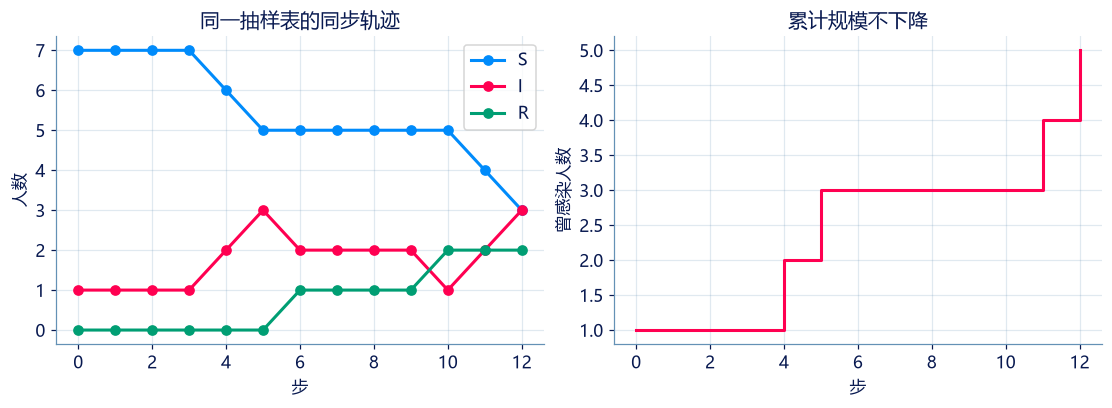

In [4]:
n=8; edges=[[i,i+1] for i in range(n-1)]
rng=np.random.default_rng(1131); steps=12
infection=rng.random((steps,n,n)).tolist(); recovery=rng.random((steps,n)).tolist()
history,ever,active=sir_fixed(n,edges,[1]+[0]*(n-1),.48,.18,infection,recovery)
counts=np.array([[row.count(j) for j in (0,1,2)] for row in history])
print('曾感染',ever,'人；更新前活跃',active,'步；各步人数和=',np.unique(counts.sum(axis=1)))
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
for j,label in enumerate(['S','I','R']): axes[0].plot(range(len(counts)),counts[:,j],marker='o',label=label)
axes[0].set(xlabel='步',ylabel='人数',title='同一抽样表的同步轨迹');axes[0].legend()
axes[1].step(range(len(history)),[sum(v!=0 for v in row) for row in history],where='post',color=PINK)
axes[1].set(xlabel='步',ylabel='曾感染人数',title='累计规模不下降');plt.show()

## 结果解释

这条曲线展示一次传播；下一节通过重复实验考察最终规模的波动。每边概率固定时，高度节点有更多独立暴露机会；比较不同网络时需控制或明确这个接触预算差异。

### 独立核对

使用手给随机表核对首两步；检查状态合法、总人数、易感不回升、恢复不倒退。

In [5]:
draws=[[[1.,1.,1.],[.2,1.,1.],[1.,1.,1.]],[[1.,1.,1.],[1.,1.,1.],[1.,.1,1.]]]
recover=[[.8,1.,1.],[.2,.8,1.]]
hand,hand_ever,hand_active=sir_fixed(3,[[0,1],[1,2]],[1,0,0],.5,.5,draws,recover)
assert hand==[[1,0,0],[1,1,0],[2,1,1]] and hand_ever==3 and hand_active==2
assert all(all(v in (0,1,2) for v in row) for row in history)
assert all(sum(v==0 for v in b)<=sum(v==0 for v in a) for a,b in zip(history,history[1:]))
assert all(sum(v==2 for v in b)>=sum(v==2 for v in a) for a,b in zip(history,history[1:]))
print('手算同步事件与状态不变量一致。')

手算同步事件与状态不变量一致。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/11-03-%E6%8E%A5%E8%A7%A6%E7%BB%93%E6%9E%84%E4%B8%8E%E4%BC%A0%E6%92%AD/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：用固定随机数重放传播

状态（state） 0=S、1=I、2=R。每步用旧状态同步更新：易感节点若任一旧感染邻居的定向抽样 edge_draws[t][i][j]<beta，则下一步变 I；旧感染节点若 recovery_draws[t][i]<gamma，则下一步变 R。返回全轨迹（trajectory）、曾感染人数和更新前仍有 I 的步数。

**函数与代码模板**

```python
def solve(
    n: int,
    edges: list[list[int]],
    initial: list[int],
    beta: float,
    gamma: float,
    infection_draws: list[list[list[float]]],
    recovery_draws: list[list[float]],
) -> tuple[list[list[int]], int, int]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `n` | `int` | 人数。 | 人 |
| `edges` | `list[list[int]]` | 无向接触边。 | 条 |
| `initial` | `list[int]` | 初态，每人取0、1或2。 | 类别 |
| `beta` | `float` | 每条感染邻边每步成功概率（probability）。 | 1 |
| `gamma` | `float` | 每个旧感染者每步恢复概率。 | 1 |
| `infection_draws` | `list[list[list[float]]]` | 逐步 n×n 定向感染抽样，只有易感i读取感染邻居j的值。 | 1 |
| `recovery_draws` | `list[list[float]]` | 逐步每人的恢复抽样。 | 1 |

**返回值**

按以下顺序返回元组：(history, ever, active_steps)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `history` | `list[list[int]]` | 含初态的同步状态序列。 | 类别 |
| `ever` | `int` | 轨迹中曾为 I 或 R 的人数。 | 人 |
| `active_steps` | `int` | 每步更新前至少有一位 I 的步数。 | 步 |

**计算规则**

本步所有感染和恢复事件（event）都只读取旧状态。新感染者不能在同一步继续传播；本步将恢复的旧感染者仍按旧 I 状态参与本步感染判定。全部事件判定完成后同时写入新状态；恰好等于阈值不触发，随机表长度相同。

**约束与边界**

- 只计算题定有限图和数值模型（model）；返回普通 Python 列表、数值或元组。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| n | 人数。 | 3 | 人 |
| edges | 无向接触边。 | [[0, 1], [1, 2]] | 条 |
| initial | 初态，每人取0、1或2。 | [1, 0, 0] | 类别 |
| beta | 每条感染邻边每步成功概率（probability）。 | 0.5 | 1 |
| gamma | 每个旧感染者每步恢复概率。 | 0.5 | 1 |
| infection_draws | 逐步 n×n 定向感染抽样，只有易感i读取感染邻居j的值。 | [[[1.0, 1.0, 1.0], [0.2, 1.0, 1.0], [1.0, 1.0, 1.0]], [[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.1, 1.0]]] | 1 |
| recovery_draws | 逐步每人的恢复抽样。 | [[0.8, 1.0, 1.0], [0.2, 0.8, 1.0]] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
n = 3
edges = [[0, 1], [1, 2]]
initial = [1, 0, 0]
beta = 0.5
gamma = 0.5
infection_draws = [[[1.0, 1.0, 1.0],
                    [0.2, 1.0, 1.0],
                    [1.0, 1.0, 1.0]],
                   [[1.0, 1.0, 1.0],
                    [1.0, 1.0, 1.0],
                    [1.0, 0.1, 1.0]]]
recovery_draws = [[0.8, 1.0, 1.0], [0.2, 0.8, 1.0]]

result = solve(n, edges, initial, beta, gamma, infection_draws, recovery_draws)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| history | 含初态的同步状态序列。 | [[1, 0, 0], [1, 1, 0], [2, 1, 1]] | 类别 |
| ever | 轨迹中曾为 I 或 R 的人数。 | 3 | 人 |
| active_steps | 每步更新前至少有一位 I 的步数。 | 2 | 步 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[1, 0, 0], [1, 1, 0], [2, 1, 1]], 3, 2)
```

**样例解释**

首例第1步只有中间节点感染；第2步旧中间节点仍可向右传播，同时左端恢复。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：用固定随机数重放传播](http://127.0.0.1:8000/chapters/11-03-%E6%8E%A5%E8%A7%A6%E7%BB%93%E6%9E%84%E4%B8%8E%E4%BC%A0%E6%92%AD/practice/?question=p11-synchronous-sir)

### 第 2 题 · 单项选择题：同步更新为何用旧状态

S— I —S 的三节点路径，第一步只有中间节点为 I。同步规则下，左端在本步被感染后，能否立刻在同一步感染其他节点？

- **A.** 能，按程序循环顺序决定。
- **B.** 不能；本步全部事件（event）只读取更新前状态（state）。
- **C.** 能，除非 gamma=0。
- **D.** 只要画图时靠得近就能。

[作答：同步更新为何用旧状态](http://127.0.0.1:8000/chapters/11-03-%E6%8E%A5%E8%A7%A6%E7%BB%93%E6%9E%84%E4%B8%8E%E4%BC%A0%E6%92%AD/practice/?question=p11-synchronous-order)

### 第 3 题 · 单项选择题：每边概率与总接触预算

两个网络有不同平均度，却把每条边每步感染概率（probability） beta 设为同值。可否将传播规模差异仅归因于结构形状？

- **A.** 可以，beta 已相同。
- **B.** 不能；高平均度节点的总暴露机会也更大，需匹配边数/度或按每人接触预算归一化。
- **C.** 可以，因为节点数相同即可。
- **D.** 不需要声明概率作用于边还是人。

[作答：每边概率与总接触预算](http://127.0.0.1:8000/chapters/11-03-%E6%8E%A5%E8%A7%A6%E7%BB%93%E6%9E%84%E4%B8%8E%E4%BC%A0%E6%92%AD/practice/?question=p11-per-edge-budget)

### 第 4 题 · 单项选择题：一次灭绝不是总体结论

固定网络和参数（parameter）下，某次传播只感染初始1人。哪项结论更稳妥？

- **A.** 模型（model）必然无法传播。
- **B.** 这一条随机轨迹（trajectory）早期灭绝；应固定比较条件并重复运行估计传播规模分布（distribution）。
- **C.** 改变随机种子（random seed）直到得到大规模传播再报告。
- **D.** 恢复机制一定不存在。

[作答：一次灭绝不是总体结论](http://127.0.0.1:8000/chapters/11-03-%E6%8E%A5%E8%A7%A6%E7%BB%93%E6%9E%84%E4%B8%8E%E4%BC%A0%E6%92%AD/practice/?question=p11-extinction-vs-mean)

**进一步阅读**

[NetworkX 图生成器与图类型说明](https://networkx.org/documentation/stable/reference/generators.html)帮助区分结构生成；传播事件规则在本节明确给出。